where does the pre-asymptotic fast decay rate come from? -> smaller snapshots to magnify
is it numeric noise? -> rand mu
is optimum local? -> map sS vs sD for rank 10

In [1]:
# test new rule of thumb? e.g. const sigmaD
# optimize sigmaS and sigmaD per snapshot for rank 10, 20, 30, 50, 100

In [2]:
from scipy.optimize import minimize
from scipy.optimize import direct, Bounds
from smooth_POD_ROM.post_processing import richardson_lucy
from smooth_POD_ROM.pre_processing import smoothen_rowwise
from smooth_POD_ROM.initial_conditions import rectangular_pulse, rect_pulse_sin, saw_tooth, triangle
from smooth_POD_ROM.reduced_order_model import optimize_hyperparameters, target_function
from smooth_POD_ROM.reduced_order_model import make_data_rw, get_data_rw, train_ROM_rw, L2_error_rw, get_predictions, get_improvement
import numpy as np
from smooth_POD_ROM.post_processing import get_sigma
import matplotlib.pyplot as plt
from datetime import datetime

In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import colormaps
from matplotlib.ticker import FormatStrFormatter
cmap = colormaps["viridis"]
page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (plot_width_in, plot_width_in/1.61803398875)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 1.0

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 45

8.030570172000001


In [4]:
def small_saw_tooth(x, mu):
    return saw_tooth(x, mu, w=0.075)

In [5]:
n_x = 1000
x = np.linspace(0, 1, n_x, endpoint=False)
case = {
    "n_x": n_x,
    "shape": x.shape,
    "x": x,
    "dx": x[1] - x[0],

    #"n_train": 10,
    #"n_test": 25,
    "n_val": 900,  # n_x * (n_train-1)/n_train
    "g": rectangular_pulse, #rectangular_pulse, saw_tooth
    "truncate": 12,
    "sigma": 0.08,

    "c": 1,
    "monitor_progress_postprocessing": False,
    "num_iter": 100,
    "monitor_convergence": False,
    "sigmaD": "calc_based_on_distance"
}
n_test = 10  # not in "case", because we handle it here and explicitely define mu_test

In [15]:
mu_test

array([[[0.33333333]],

       [[0.36666667]],

       [[0.4       ]],

       [[0.43333333]],

       [[0.46666667]],

       [[0.5       ]],

       [[0.53333333]],

       [[0.56666667]],

       [[0.6       ]],

       [[0.63333333]]])

In [16]:
g = case["g"]
x = case["g"]
shape = case["shape"]
num_iter1 = 100
num_iter2 = 250

#def estimate_dN():

# num_iter = 200
NN = np.arange(3, 150, 10)
dN_ROM = np.zeros(len(NN))
dN_sROM = np.zeros(len(NN))
dN_sROMs = np.zeros(len(NN))
dN_sROMs2 = np.zeros(len(NN))
dN_sig = np.zeros(len(NN))
dN_c = np.zeros(len(NN))

for i, rank in enumerate(NN):
    print(rank)
    case["num_iter"] = num_iter1
    case["rank"] = n_train = rank
    
    mu_min, mu_max = np.array([0]), np.array([1])
    # mu_train = np.atleast_2d(np.random.rand(n_train,)[:, None] * (mu_max - mu_min) + mu_min)
    # mu_min, mu_max = np.min(mu_train), np.max(mu_train)
    # mu_test = np.atleast_2d(np.random.rand(n_test,)[:, None] * (mu_max - mu_min) + mu_min)

    mu_train = np.linspace(mu_min, mu_max, n_train, endpoint=False)
    mu_min, mu_max = mu_train[1], mu_train[2]
    mu_test = np.linspace(mu_min, mu_max, n_test, endpoint=False)

    
    case["mu_train"], case["mu_test"] = mu_train, mu_test
    parameters = optimize_hyperparameters(case)
    case["sigma"],  case["c"]  = parameters

    case["num_iter"] = num_iter2
    X_train, X_train_s= get_data_rw(mu_train, **case)
    X_test, X_test_s  = get_data_rw(mu_test, **case)
    
    my_ROM = train_ROM_rw(mu_train, X_train)
    my_sROM = train_ROM_rw(mu_train, X_train_s)

    X_test_ROM = my_ROM.predict(mu_test).snapshots_matrix
    X_test_sROM, X_test_sROMs = get_predictions(my_sROM, mu_test, **case)
    mean_ROM, mean_sROM, mean_sROMs, improvement = get_improvement(X_test, X_test_ROM, X_test_sROM, X_test_sROMs)

    dN_ROM[i] = mean_ROM
    dN_sROM[i] = mean_sROM
    dN_sROMs[i] = mean_sROMs
    dN_sig[i] = parameters[0]
    dN_c[i] = parameters[1]

3
100, 0.41716667, 5.00000000, 0.28653289, 0.26295334, 0.26263488, -8.3404
100, 0.69461111, 5.00000000, 0.28653289, 0.26387183, 0.26386952, -7.9095
100, 0.13972222, 5.00000000, 0.28653289, 0.24750424, 0.19050357, -33.5142
100, 0.41716667, 8.33333333, 0.28653289, 0.26295334, 0.26208204, -8.5333
100, 0.41716667, 1.66666667, 0.28653289, 0.26295334, 0.26244853, -8.4054
100, 0.13972222, 8.33333333, 0.28653289, 0.24750424, 0.20672364, -27.8534
100, 0.13972222, 1.66666667, 0.28653289, 0.24750424, 0.18095029, -36.8483
100, 0.69461111, 8.33333333, 0.28653289, 0.26387183, 0.26386981, -7.9094
100, 0.69461111, 1.66666667, 0.28653289, 0.26387183, 0.26387453, -7.9078
100, 0.23220370, 1.66666667, 0.28653289, 0.25492105, 0.21478494, -25.0400
100, 0.04724074, 1.66666667, 0.28653289, 0.25301007, 0.31555935, 10.1302
100, 0.13972222, 2.77777778, 0.28653289, 0.24750424, 0.16455096, -42.5717
100, 0.13972222, 0.55555556, 0.28653289, 0.24750424, 0.23322844, -18.6033
100, 0.23220370, 2.77777778, 0.28653289, 0.

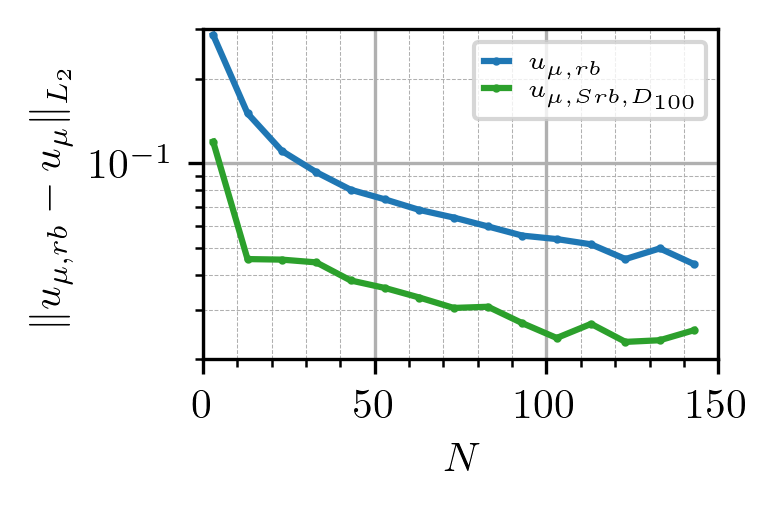

In [17]:

fig, ax = plt.subplots(figsize=(page_width_in / 2, page_width_in / 3))
plt.plot(NN, dN_ROM, "C0.-", ms=2, label=r"$u_{\mu,rb}$")
# plt.plot(NN, esROM, "C1--", ms=2, label="$u_{rb,S}$")
plt.plot(NN, dN_sROMs, "C2.-", ms=2, label=r"$u_{\mu,Srb,D_{100}}$")
# plt.plot(NN, dN_sROMs2, "C3.-", ms=2, label="$u_{\mu,rb,D_{1000}}$")
# plt.plot(mu_val, esROMs2, "C3<-", ms=4, markevery=(20, markevery), label="$u_{rb,D_{100}}$")
plt.legend()
plt.ylabel(r"$\|u_{\mu,rb}-u_{\mu}\|_{L_2}$")
plt.xlabel(r"$N$")
# plt.ylim(0, 0.4)
plt.legend()
ax.set_xticks(np.linspace(0, 250, 26, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, 0.4, 19, endpoint=True), minor=True)
plt.grid(True, which="minor", linestyle="--", lw=0.25)
plt.grid(True, which="major", linestyle="-")
ax.set_yscale("log")
plt.xlim(0, 150)
plt.ylim(2e-2, 0.3)
plt.show()

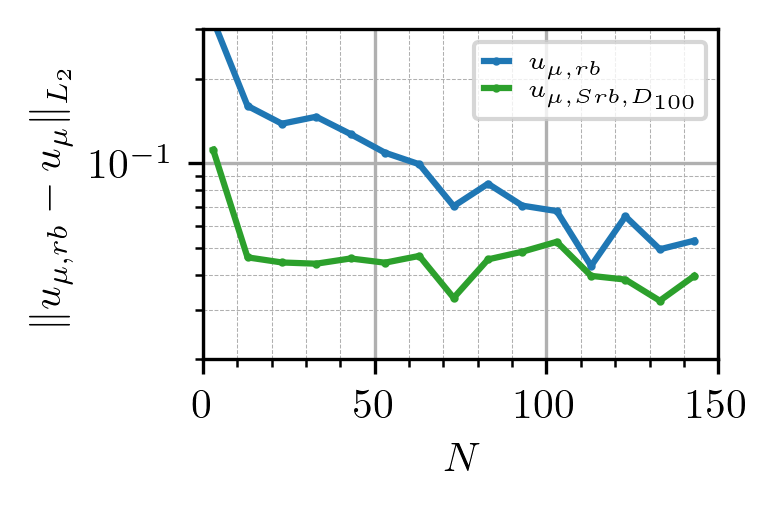

In [7]:

fig, ax = plt.subplots(figsize=(page_width_in / 2, page_width_in / 3))
plt.plot(NN, dN_ROM, "C0.-", ms=2, label=r"$u_{\mu,rb}$")
# plt.plot(NN, esROM, "C1--", ms=2, label="$u_{rb,S}$")
plt.plot(NN, dN_sROMs, "C2.-", ms=2, label=r"$u_{\mu,Srb,D_{100}}$")
# plt.plot(NN, dN_sROMs2, "C3.-", ms=2, label="$u_{\mu,rb,D_{1000}}$")
# plt.plot(mu_val, esROMs2, "C3<-", ms=4, markevery=(20, markevery), label="$u_{rb,D_{100}}$")
plt.legend()
plt.ylabel(r"$\|u_{\mu,rb}-u_{\mu}\|_{L_2}$")
plt.xlabel(r"$N$")
# plt.ylim(0, 0.4)
plt.legend()
ax.set_xticks(np.linspace(0, 250, 26, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, 0.4, 19, endpoint=True), minor=True)
plt.grid(True, which="minor", linestyle="--", lw=0.25)
plt.grid(True, which="major", linestyle="-")
ax.set_yscale("log")
plt.xlim(0, 150)
plt.ylim(2e-2, 0.3)
plt.show()

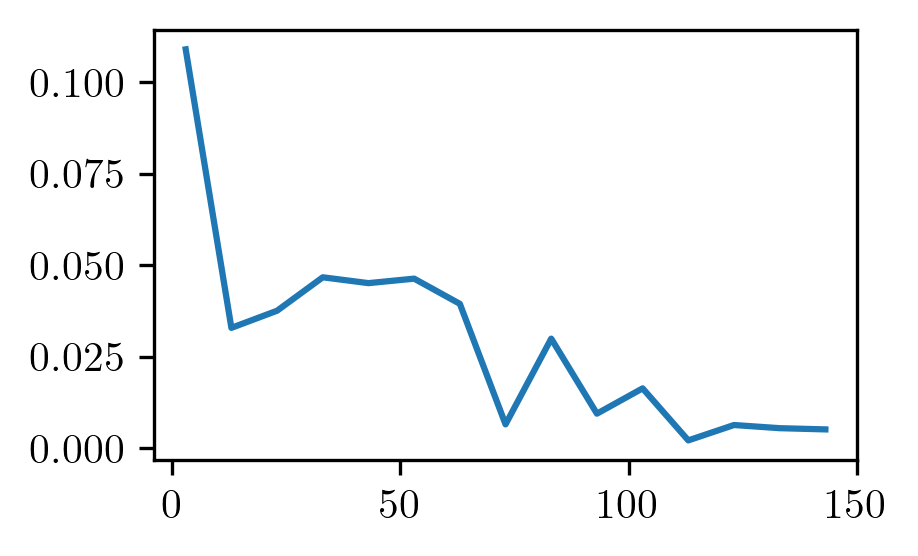

In [8]:
plt.plot(NN, dN_sig)